Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as tts
from sklearn.datasets import make_regression

Generating the Test Data

In [3]:
np.random.seed(42)

X, y, true_coef = make_regression(
    n_samples = 200, #n > p
    n_features = 5,
    n_informative = 5,
    noise = 10.0,
    coef = True
)

X_train, X_test, y_train, y_test = tts(X, y, test_size = 0.2, random_state = 42)
X_train_new, X_test_new, y_train_new, y_test_new = tts(
    X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}\n")
print(f"Testing set: {X_test.shape}\n")
print(f"True Coefficients: {true_coef}\n")

print(f"X_train unchanged? {np.allclose(X_train, X_train_new)}")
print(f"y_train unchanged? {np.allclose(y_train, y_train_new)}")

Training set: (160, 5)

Testing set: (40, 5)

True Coefficients: [ 3.15861448 10.45678403 63.64302495 16.74825823 70.64757265]

X_train unchanged? True
y_train unchanged? True


Implementation of Centered OLS

In [4]:
class OLSRegressor:

  def __init__(self):

    """
    What to store:
    1. self.beta_: coefficients (p-dim)
    2. self.intercept_: intercept term (scalar)
    3. self.X_mean_: feature means (for centering data)
    4. self.y_mean_: target mean (for intercept calculation)
    """

    self.beta_ = None
    self.intercept_ = None
    self.X_mean_ = None
    self.y_mean_ = None

  def fit(self, X, y):

    """
    Fit OLS using normal equation using centered data.

    Step:
    1. Store means of X and y
    2. Center X and y
    3. Solve: beta = (X^T X)^(-1) X^T y
    4. Compute intercept: beta_0 = y_mean - X_mean^T beta
    """

    #1. Compute and store means
    self.X_mean_ = np.mean(X, axis = 0)
    self.y_mean_ = np.mean(y)

    #2. Center the data
    X_centered = X - self.X_mean_
    y_centered = y - self.y_mean_

    #3. Solve normal equation

    X_tX = X_centered.T @ X_centered
    X_ty = X_centered.T @ y_centered

    self.beta_ = np.linalg.solve(X_tX, X_ty)

    #4. Compute Intercept

    self.intercept_ = self.y_mean_

    return self

  def predict(self, X):

    """
    Predict using y_pred = beta_0 + X_centered @ beta

    !!Centered X uses training means, not test means.
    """

    X_centered = X - self.X_mean_

    return self.intercept_ + X_centered @ self.beta_

  def get_hat_matrix(self, X):

    """
    Compute H = X(X^T X)^(-1) X^T on centered X

    Returns:
    H: matrix of size (n, n) - Hat matrix
    """

    X_centered = X - self.X_mean_
    X_tX = X_centered.T @ X_centered

    H = X_centered @ np.linalg.solve(X_tX, X_centered.T)

    return H

  def get_residuals(self, X, y):

    """
    Compute Residuals: r = y - y_pred

    Also verifu orthogonality: X^T e should be 0
    """

    #1. Get predictions
    y_pred = self.predict(X)

    #2. Compute Residuals

    r = y - y_pred

    #3. Checking orthogonality

    X_centered = X - self.X_mean_

    ortho_check = X_centered.T @ r

    print(f"X^T r is: {ortho_check}\n")
    print(f"Max absolute value: {np.max(np.abs(ortho_check)):.2e}\n")

    if np.allclose(ortho_check, 0, atol = 1e-8):
      print("Residuals are orthogonal to X.")

    return r

  def fit_svd(self, X, y):

    """
    Fit OLS using SVD decomposition.

    For centered X = USV^T
    """

    self.X_mean_ = X.mean(axis = 0)
    self.y_mean_ = y.mean()

    X_centered = X - self.X_mean_
    y_centered = y - self.y_mean_

    U, S, Vt = np.linalg.svd(X_centered, full_matrices = False)

    self.beta_ = Vt.T @ np.diag(1/S) @ U.T @ y_centered

    self.intercept_ = self.y_mean_

    self.singular_values_ = S
    self.condition_number_ = S[0]/S[-1]


    return self


Testing on Sample Data

In [5]:
model_normal = OLSRegressor()
model_normal.fit(X_train, y_train)

print(f"Beta Shape: {model_normal.beta_.shape} same as ({X_train.shape[1]},)\n")
print(f"Intercept: {model_normal.intercept_:.4f} (scalar).\n")
print(f"X_mean: {model_normal.X_mean_.shape}\n")

y_train_pred = model_normal.predict(X_train)
y_test_pred = model_normal.predict(X_test)

print(f"Trained prediction shape: {y_train_pred.shape}\n")
print(f"Test prediction shape: {y_test_pred.shape}\n")

residual_train = y_train - y_train_pred

#Computing R^2
SS_res = np.sum(residual_train ** 2)
SS_tot = np.sum((y_train - y_train.mean()) ** 2)
r2_train = 1 - SS_res/SS_tot

print(f"R2 Score: {r2_train:.4f}")

print(f"True Coeffs: {true_coef}\n")
print(f"Estimated Coeffs: {model_normal.beta_}\n")
print(f"Estimation Error: {np.linalg.norm(true_coef - model_normal.beta_):.4f}")

Beta Shape: (5,) same as (5,)

Intercept: 9.8007 (scalar).

X_mean: (5,)

Trained prediction shape: (160,)

Test prediction shape: (40,)

R2 Score: 0.9890
True Coeffs: [ 3.15861448 10.45678403 63.64302495 16.74825823 70.64757265]

Estimated Coeffs: [ 2.83386855 11.01451652 64.88463996 17.94510226 69.86671833]

Estimation Error: 2.0001


Testing on Sample Data

In [6]:
H = model_normal.get_hat_matrix(X_train)

print(f"Shape: {H.shape}\n")
print(f"Is symmetric? {np.allclose(H, H.T)}\n")
print(f"Is idempotent? {np.allclose(H @ H, H)}\n")
print(f"Trace: {np.trace(H):.4f} - should be {X_train.shape[1]}\n")

eigenvals = np.linalg.eigvals(H)
unique_eigenvals = np.unique(np.round(eigenvals, 10))

print(f"Unique eigenvalues: {unique_eigenvals}\n")
print(f"Number of eigenvalues approx 1: {np.sum(np.isclose(eigenvals, 1))}\n")
print(f"Number of eigenvalues approx 0: {np.sum(np.isclose(eigenvals, 0))}\n")

residuals = model_normal.get_residuals(X_train, y_train)

print(f"Residual sum: {np.sum(residuals):.2f}\n")
print(f"Residuals std: {np.std(residuals):.4f}")

Shape: (160, 160)

Is symmetric? True

Is idempotent? True

Trace: 5.0000 - should be 5

Unique eigenvalues: [0.+0.j 1.+0.j]

Number of eigenvalues approx 1: 5

Number of eigenvalues approx 0: 155

X^T r is: [ 6.10178574e-13 -2.70006240e-13  4.35029790e-12  2.84217094e-13
  1.40309986e-12]

Max absolute value: 4.35e-12

Residuals are orthogonal to X.
Residual sum: -0.00

Residuals std: 10.1164


Testing SVD v.s Normal Equation on Sample Data

In [7]:
model_normal = OLSRegressor()
model_normal.fit(X_train, y_train)

model_svd = OLSRegressor()
model_svd.fit_svd(X_train, y_train)

print(f"Normal beta: {model_normal.beta_}\n")
print(f"SVD beta: {model_svd.beta_}\n")
print(f"Difference: {np.linalg.norm(model_normal.beta_ - model_svd.beta_):.2e}\n")

print(f"Condition number: {model_svd.condition_number_:.2f}\n")
print(f"Singular values: {model_svd.singular_values_}\n")

y_pred_normal = model_normal.predict(X_test)
y_pred_svd = model_svd.predict(X_test)

print(f"Prediction difference: {np.linalg.norm(y_pred_normal - y_pred_svd):.2e}\n")

print(f"True coefficients: {true_coef}\n")
print(f"Normal estimation error: {np.linalg.norm(true_coef - model_normal.beta_):.4f}\n")
print(f"SVD estimation error: {np.linalg.norm(true_coef - model_svd.beta_):.4f}\n")

Normal beta: [ 2.83386855 11.01451652 64.88463996 17.94510226 69.86671833]

SVD beta: [ 2.83386855 11.01451652 64.88463996 17.94510226 69.86671833]

Difference: 4.50e-14

Condition number: 1.20

Singular values: [13.77383968 12.41084329 12.28844777 11.85219629 11.49098733]

Prediction difference: 2.77e-13

True coefficients: [ 3.15861448 10.45678403 63.64302495 16.74825823 70.64757265]

Normal estimation error: 2.0001

SVD estimation error: 2.0001



RidgeRegressor Implementation

In [18]:
class RidgeRegressor:

  def __init__(self, lambda_ = 1.0):

    """
    Ridge Regression with L2 penalty.

    Parameters:
    lamda_: float - Regularization strength.
    """

    self.lambda_ = lambda_
    self.beta = None
    self.intercept_ = None
    self.X_mean_ = None
    self.y_mean_ = None

  def fit(self, X, y):

    """
    Fit Ridge regression using normal equation.

    Steps:
    1. Compute means.
    2. Center variables
    3. Solve: (X^T X + lambda I)^(-1) beta = X^T y
    4. Set intercept = y_mean
    """

    self.X_mean_ = X.mean(axis = 0)
    self.y_mean_ = y.mean()

    X_centered = X - self.X_mean_
    y_centered = y - self.y_mean_

    X_tX = X_centered.T @ X_centered
    X_ty = X_centered.T @ y_centered

    n, p = X_centered.shape
    I = np.eye(p)

    X_tX_ridge = X_tX + self.lambda_ * I

    self.beta_ = np.linalg.solve(X_tX_ridge, X_ty)

    self.intercept_ = self.y_mean_

    return self

  def predict(self, X):

    X_centered = X - self.X_mean_

    return self.intercept_ + X_centered @ self.beta_

  def fit_svd(self, X, y):

    """
    Fit Ridge regression usign SVD decomposition.

    This is to show how ridge shrinks each singular value contribution.
    """

    self.X_mean_ = X.mean(axis = 0)
    self.y_mean_ = y.mean()

    X_centered = X - self.X_mean_
    y_centered = y - self.y_mean_

    U, S, Vt = np.linalg.svd(X_centered, full_matrices = False)

    shrinkage = S / (S ** 2 + self.lambda_)

    self.beta_ = Vt.T @ np.diag(shrinkage) @ U.T @ y_centered

    self.intercept_ = self.y_mean_

    self.singular_values_ = S
    self.condition_number = S[0]/S[-1]
    self.shrinkage_factors_ = shrinkage

    return self

  def fit_augmented(self, X, y):

    """
    Fit ridge by solving OLS on augmented data.

    Augmented problem:
    X_aug = [X; sqrt(lambda)I] - vertically stacked
    y_aug = [y; 0] - vertically stacked
    """

    self.X_mean_ = X.mean(axis = 0)
    self.y_mean_ = y.mean()

    X_centered = X - self.X_mean_
    y_centered = y - self.y_mean_

    n, p = X_centered.shape
    I = np.eye(p)

    X_aug = np.vstack([X_centered, np.sqrt(self.lambda_) * I])
    y_aug = np.concatenate([y_centered, np.zeros(p)])

    self.beta_ = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y_aug)

    self.intercept_ = self.y_mean_

    return self

  def loocv_mse(self, X, y):

    """
    Compute LOOCV MSE using fast formula.

    Returns:
    mse_: float - Mean squared LOOCv error.
    """

    self.X_mean_ = X.mean(axis = 0)
    self.y_mean_ = y.mean()

    e = y - self.predict(X)

    X_centered = X - self.X_mean_
    y_centered = y - self.y_mean_

    X_tX = X_centered.T @ X_centered
    X_ty = X_centered.T @ y_centered

    n, p = X_centered.shape
    I = np.eye(p)

    H = X_centered @np.linalg.solve(X_tX + self.lambda_ * np.eye(p), X_centered.T)

    H_diag = np.diag(H)

    loocv_errors = e / (1 - H_diag)

    return np.mean(loocv_errors ** 2)

  def fit_dual(self, X, y):

    """
    Fit Ridge using dual formulation.

    Useful when n << p.
    """

    self.X_mean_ = X.mean(axis = 0)
    self.y_mean_ = y.mean()

    X_centered = X - self.X_mean_
    y_centered = y - self.y_mean_

    # Kernel Matrix K = XX^T
    K = X_centered @ X_centered.T # (n x n matrix)

    n = X_centered.shape[0]

    alpha = np.linalg.solve(K + self.lambda_ * np.eye(n), y_centered)

    self.alpha_ = alpha

    self.beta_ = X_centered.T @ self.alpha_


    self.X_train_centered_ = X_centered

    self.intercept_ = self.y_mean_

    return self

  def predict_dual(self, X):

    """
    Predict using dual formation.
    """

    X_centered = X - self.X_mean_

    K_test = self.X_train_centered_ @ X_centered.T

    y_pred_centered = self.alpha_ @ K_test

    return self.intercept_ + y_pred_centered

  def dof(self, X):

    """
    Compute effective degrees of freedom for ridge.
    """

    self.X_mean_ = X.mean(axis = 0)

    X_centered = X - self.X_mean_

    _, S, _ = np.linalg.svd(X_centered, full_matrices = False)

    df = np.sum(S ** 2 / (S ** 2 + self.lambda_))

    return df

Testing on Sample Data

In [8]:
lambdas = [0, 0.1, 1, 10, 100, 1000]

for lam in lambdas:
    model = RidgeRegressor(lambda_ = lam)
    model.fit(X_train, y_train)

    beta_norm = np.linalg.norm(model.beta_)
    y_pred = model.predict(X_test)
    mse = np.mean((y_test - y_pred) ** 2)

    print(f"lambda = {lam:6.1f}: ||beta|| = {beta_norm:6.2f}, Test MSE = {mse:8.2f}")

model_ols = OLSRegressor()
model_ols.fit(X_train, y_train)
y_pred_ols = model_ols.predict(X_test)
mse_ols = np.mean((y_test - y_pred_ols) ** 2)

print(f"\nOLS:      ||beta|| = {np.linalg.norm(model_ols.beta_):6.2f}, Test MSE = {mse_ols:8.2f}")

lambda =    0.0: ||beta|| =  97.69, Test MSE =    85.06
lambda =    0.1: ||beta|| =  97.62, Test MSE =    84.90
lambda =    1.0: ||beta|| =  97.05, Test MSE =    83.87
lambda =   10.0: ||beta|| =  91.70, Test MSE =   105.96
lambda =  100.0: ||beta|| =  59.18, Test MSE =  1465.78
lambda = 1000.0: ||beta|| =  13.08, Test MSE =  6956.52

OLS:      ||beta|| =  97.69, Test MSE =    85.06


Testing Ridge SVD on Sample Data

In [9]:
model_ridge_normal = RidgeRegressor(lambda_ = 1.0)
model_ridge_normal.fit(X_train, y_train)

model_ridge_svd = RidgeRegressor(lambda_ = 1.0)
model_ridge_svd.fit_svd(X_train, y_train)

print(f"Normal beta: {model_ridge_normal.beta_}")
print(f"SVD beta: {model_ridge_svd.beta_}")
print(f"Difference: {np.linalg.norm(model_ridge_normal.beta_ - model_ridge_svd.beta_):.2e}")

print(f"Singular values:")
for i, s in enumerate(model_ridge_svd.singular_values_):
    ols_weight = 1/s
    ridge_weight = s / (s**2 + model_ridge_svd.lambda_)

    retention = (s**2) / (s**2 + model_ridge_svd.lambda_)

    print(f"s_{i+1}={s:.2f}: Ridge retains {retention*100:.1f}% of OLS weight")

print(f"Shrinkage factors (s/(s²+λ)):")
for i, (s, shrink) in enumerate(zip(model_ridge_svd.singular_values_,
                                      model_ridge_svd.shrinkage_factors_)):

    ols_factor = 1/s
    percent_of_ols = shrink / ols_factor * 100
    print(f"  Direction {i+1}: {shrink:.6f} ({percent_of_ols:.1f}% of OLS)")

Normal beta: [ 2.86506835 10.94378116 64.47217686 17.81093809 69.4070294 ]
SVD beta: [ 2.86506835 10.94378116 64.47217686 17.81093809 69.4070294 ]
Difference: 4.41e-14
Singular values:
s_1=13.77: Ridge retains 99.5% of OLS weight
s_2=12.41: Ridge retains 99.4% of OLS weight
s_3=12.29: Ridge retains 99.3% of OLS weight
s_4=11.85: Ridge retains 99.3% of OLS weight
s_5=11.49: Ridge retains 99.2% of OLS weight
Shrinkage factors (s/(s²+λ)):
  Direction 1: 0.072221 (99.5% of OLS)
  Direction 2: 0.080055 (99.4% of OLS)
  Direction 3: 0.080842 (99.3% of OLS)
  Direction 4: 0.083776 (99.3% of OLS)
  Direction 5: 0.086371 (99.2% of OLS)


Visualizing the shrinkage

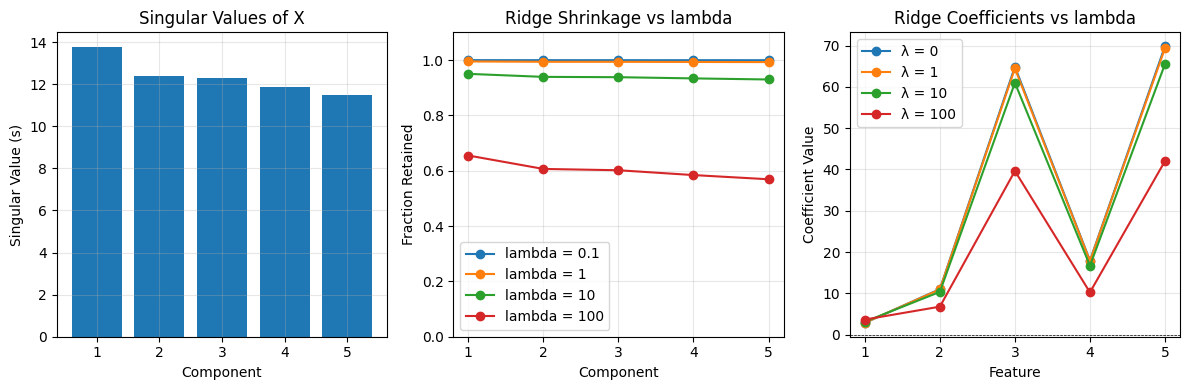

In [10]:
plt.figure(figsize = (12, 4))

plt.subplot(1, 3, 1)
plt.bar(range(1, 6), model_ridge_svd.singular_values_)
plt.xlabel('Component')
plt.ylabel('Singular Value (s)')
plt.title('Singular Values of X')
plt.grid(True, alpha = 0.3)

plt.subplot(1, 3, 2)
lambdas_viz = [0.1, 1, 10, 100]
for lam in lambdas_viz:
    shrinkage = model_ridge_svd.singular_values_ ** 2 / (
        model_ridge_svd.singular_values_ ** 2 + lam)
    plt.plot(range(1, 6), shrinkage, marker = 'o', label = f'lambda = {lam}')

plt.xlabel('Component')
plt.ylabel('Fraction Retained')
plt.title('Ridge Shrinkage vs lambda')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.ylim(0, 1.1)

plt.subplot(1, 3, 3)
lambdas_compare = [0, 1, 10, 100]
for lam in lambdas_compare:
    model_temp = RidgeRegressor(lambda_ = lam)
    model_temp.fit(X_train, y_train)
    plt.plot(range(1, 6), model_temp.beta_, marker = 'o', label = f'λ = {lam}')

plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficients vs lambda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color = 'black', linestyle = '--', linewidth = 0.5)

plt.tight_layout()
plt.show()

Testing Rigde OLS on Augmented Data

In [11]:
model_ridge_normal = RidgeRegressor(lambda_ = 10.0)
model_ridge_normal.fit(X_train, y_train)

model_ridge_svd = RidgeRegressor(lambda_ = 10.0)
model_ridge_svd.fit_svd(X_train, y_train)

model_ridge_aug = RidgeRegressor(lambda_ = 10.0)
model_ridge_aug.fit_augmented(X_train, y_train)

print(f"Normal:    beta = {model_ridge_normal.beta_}")
print(f"SVD:       beta = {model_ridge_svd.beta_}")
print(f"Augmented: beta = {model_ridge_aug.beta_}")

print(f"\nDifference (Normal vs SVD):       {np.linalg.norm(model_ridge_normal.beta_ - model_ridge_svd.beta_):.2e}")
print(f"Difference (Normal vs Augmented): {np.linalg.norm(model_ridge_normal.beta_ - model_ridge_aug.beta_):.2e}")
print(f"Difference (SVD vs Augmented):    {np.linalg.norm(model_ridge_svd.beta_ - model_ridge_aug.beta_):.2e}")

Normal:    beta = [ 3.1055408  10.3481739  60.98525287 16.68795857 65.5271568 ]
SVD:       beta = [ 3.1055408  10.3481739  60.98525287 16.68795857 65.5271568 ]
Augmented: beta = [ 3.1055408  10.3481739  60.98525287 16.68795857 65.5271568 ]

Difference (Normal vs SVD):       3.45e-14
Difference (Normal vs Augmented): 0.00e+00
Difference (SVD vs Augmented):    3.45e-14


Finding optimal lambda via grid search

In [12]:
lambda_values = np.logspace(-2, 3, 50)
train_mses = []
test_mses = []
loocv_mses = []

print("Searching for optimal lambda...")
for lam in lambda_values:

    model = RidgeRegressor(lambda_ = lam)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = np.mean((y_train - y_train_pred) ** 2)
    test_mse = np.mean((y_test - y_test_pred) ** 2)
    loocv_mse = model.loocv_mse(X_train, y_train)

    train_mses.append(train_mse)
    test_mses.append(test_mse)
    loocv_mses.append(loocv_mse)

optimal_idx_loocv = np.argmin(loocv_mses)
optimal_idx_test = np.argmin(test_mses)

print(f"By LOOCV: lambda = {lambda_values[optimal_idx_loocv]:.4f}, MSE = {loocv_mses[optimal_idx_loocv]:.2f}")
print(f"By Test:  lambda = {lambda_values[optimal_idx_test]:.4f}, MSE = {test_mses[optimal_idx_test]:.2f}")

Searching for optimal lambda...
By LOOCV: lambda = 0.0100, MSE = 109.38
By Test:  lambda = 1.7575, MSE = 83.51


Viasual Lambda Selection

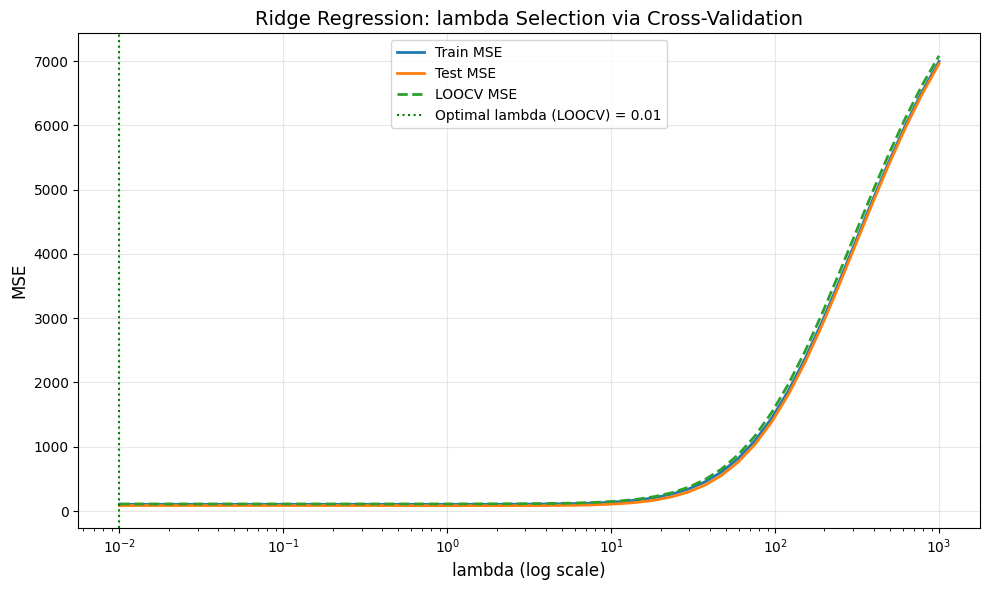

In [13]:
plt.figure(figsize = (10, 6))

plt.plot(lambda_values, train_mses, label = 'Train MSE', linewidth = 2)
plt.plot(lambda_values, test_mses, label = 'Test MSE', linewidth = 2)
plt.plot(lambda_values, loocv_mses, label = 'LOOCV MSE', linewidth = 2, linestyle = '--')

plt.axvline(lambda_values[optimal_idx_loocv], color = 'green',
            linestyle = ':', label = f'Optimal lambda (LOOCV) = {lambda_values[optimal_idx_loocv]:.2f}')

plt.xscale('log')
plt.xlabel('lambda (log scale)', fontsize = 12)
plt.ylabel('MSE', fontsize = 12)
plt.title('Ridge Regression: lambda Selection via Cross-Validation', fontsize = 14)
plt.legend(fontsize = 10)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

Quatifying Bias-Variance Decomposition

In [14]:
model_ols = OLSRegressor()
model_ols.fit(X_train, y_train)

model_ridge_opt = RidgeRegressor(lambda_ = 1.76)
model_ridge_opt.fit(X_train, y_train)

y_train_pred_ols = model_ols.predict(X_train)
y_train_pred_ridge = model_ridge_opt.predict(X_train)

y_test_pred_ols = model_ols.predict(X_test)
y_test_pred_ridge = model_ridge_opt.predict(X_test)

train_mse_ols = np.mean((y_train - y_train_pred_ols) ** 2)
train_mse_ridge = np.mean((y_train - y_train_pred_ridge) ** 2)

test_mse_ols = np.mean((y_test - y_test_pred_ols) ** 2)
test_mse_ridge = np.mean((y_test - y_test_pred_ridge) ** 2)

print(f"\n{'Method':<10} {'Train MSE':>12} {'Test MSE':>12} {'||beta||':>10}\n")
print(f"{'OLS':<10} {train_mse_ols:12.2f} {test_mse_ols:12.2f} {np.linalg.norm(model_ols.beta_):10.2f}")
print(f"{'Ridge':<10} {train_mse_ridge:12.2f} {test_mse_ridge:12.2f} {np.linalg.norm(model_ridge_opt.beta_):10.2f}")

print(f"\n{'Difference':<10} {train_mse_ridge - train_mse_ols:+12.2f} {test_mse_ridge - test_mse_ols:+12.2f} {np.linalg.norm(model_ridge_opt.beta_) - np.linalg.norm(model_ols.beta_):+10.2f}")

print(f"{'Feature':<10} {'True':>10} {'OLS':>10} {'Ridge':>10} {'Shrinkage %':>12}")

for i, (true_coef, ols_coef, ridge_coef) in enumerate(zip(true_coef, model_ols.beta_, model_ridge_opt.beta_)):

    shrinkage = (1 - abs(ridge_coef/ols_coef)) * 100 if ols_coef != 0 else 0
    print(f"{'beta_'+str(i+1):<10} {true_coef:10.2f} {ols_coef:10.2f} {ridge_coef:10.2f} {shrinkage:11.1f}%")


Method        Train MSE     Test MSE   ||beta||

OLS              102.34        85.06      97.69
Ridge            103.52        83.51      96.58

Difference        +1.18        -1.55      -1.11
Feature          True        OLS      Ridge  Shrinkage %
beta_1           3.16       2.83       2.89        -1.9%
beta_2          10.46      11.01      10.89         1.1%
beta_3          63.64      64.88      64.16         1.1%
beta_4          16.75      17.95      17.71         1.3%
beta_5          70.65      69.87      69.06         1.2%


Testing Dual versus Primal

In [15]:
lambda_test = 10.0

model_primal = RidgeRegressor(lambda_ = lambda_test)
model_primal.fit(X_train, y_train)

model_svd = RidgeRegressor(lambda_ = lambda_test)
model_svd.fit_svd(X_train, y_train)

model_aug = RidgeRegressor(lambda_ = lambda_test)
model_aug.fit_augmented(X_train, y_train)

model_dual = RidgeRegressor(lambda_ = lambda_test)
model_dual.fit_dual(X_train, y_train)

print(f"Primal:    beta = {model_primal.beta_}")
print(f"SVD:       beta = {model_svd.beta_}")
print(f"Augmented: beta = {model_aug.beta_}")
print(f"Dual:      beta = {model_dual.beta_}")

print(f"Primal vs Dual: {np.linalg.norm(model_primal.beta_ - model_dual.beta_):.2e}")

y_test_pred_primal = model_primal.predict(X_test)
y_test_pred_dual = model_dual.predict_dual(X_test)

print(f"\nPrediction difference: {np.linalg.norm(y_test_pred_primal - y_test_pred_dual):.2e}")

import time

print(f"Matrix sizes:")
print(f"  Primal: ({X_train.shape[1]} × {X_train.shape[1]}) = ({X_train.shape[1] ** 2} elements)")
print(f"  Dual:   ({X_train.shape[0]} × {X_train.shape[0]}) = ({X_train.shape[0] ** 2} elements)")

t0 = time.time()

for _ in range(100):

    model_primal.fit(X_train, y_train)

t_primal = time.time() - t0

t0 = time.time()

for _ in range(100):

    model_dual.fit_dual(X_train, y_train)

t_dual = time.time() - t0

print(f"\nTiming (100 iterations):")
print(f"  Primal: {t_primal:.4f}s")
print(f"  Dual:   {t_dual:.4f}s")
print(f"  Ratio:  {t_dual/t_primal:.2f}x")

Primal:    beta = [ 3.1055408  10.3481739  60.98525287 16.68795857 65.5271568 ]
SVD:       beta = [ 3.1055408  10.3481739  60.98525287 16.68795857 65.5271568 ]
Augmented: beta = [ 3.1055408  10.3481739  60.98525287 16.68795857 65.5271568 ]
Dual:      beta = [ 3.1055408  10.3481739  60.98525287 16.68795857 65.5271568 ]
Primal vs Dual: 4.56e-14

Prediction difference: 2.76e-13
Matrix sizes:
  Primal: (5 × 5) = (25 elements)
  Dual:   (160 × 160) = (25600 elements)

Timing (100 iterations):
  Primal: 0.0174s
  Dual:   0.1296s
  Ratio:  7.46x


Visualizing the prior

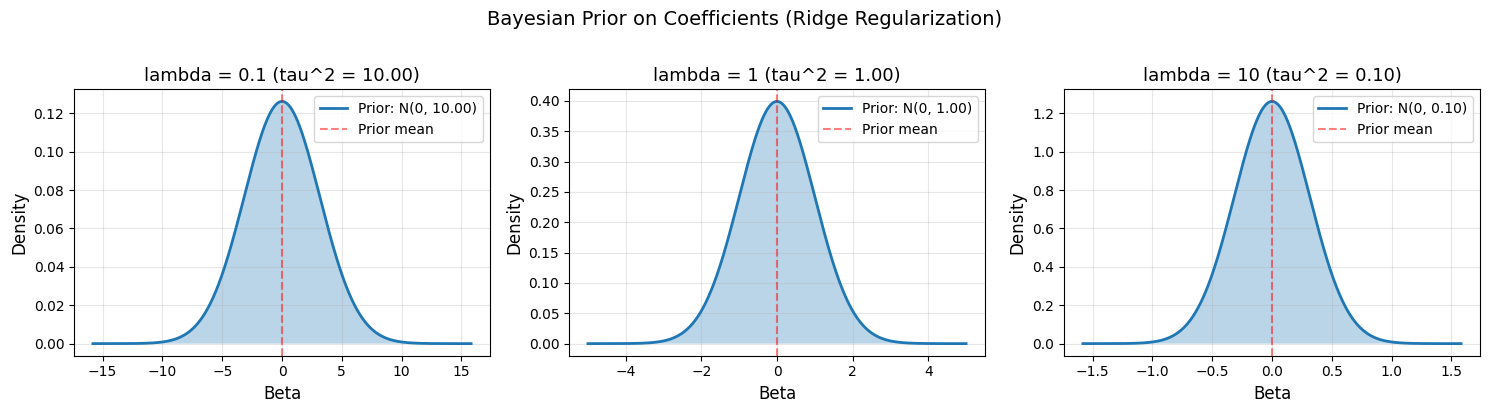

Ridge regularization = Gaussian prior on coefficients

For optimal lambda = 1.76:
  Prior variance tau^2 = 0.568
  Prior std tau = 0.754


In [16]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

lambdas_bayes = [0.1, 1, 10]
for idx, lam in enumerate(lambdas_bayes):

    tau_sq = 1 / lam
    tau = np.sqrt(tau_sq)

    beta_range = np.linspace(-5 * tau, 5 * tau, 1000)
    prior = (1/np.sqrt(2 * np.pi * tau_sq)) * np.exp(-beta_range ** 2 / (2 * tau_sq))

    axes[idx].plot(beta_range, prior, linewidth = 2, label = f'Prior: N(0, {tau_sq:.2f})')
    axes[idx].axvline(0, color = 'red', linestyle = '--', alpha = 0.5, label = 'Prior mean')
    axes[idx].fill_between(beta_range, 0, prior, alpha = 0.3)

    axes[idx].set_xlabel('Beta', fontsize = 12)
    axes[idx].set_ylabel('Density', fontsize = 12)
    axes[idx].set_title(f'lambda = {lam} (tau^2 = {tau_sq:.2f})', fontsize = 13)
    axes[idx].legend()
    axes[idx].grid(True, alpha = 0.3)

plt.suptitle('Bayesian Prior on Coefficients (Ridge Regularization)', fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()

print("Ridge regularization = Gaussian prior on coefficients")
print(f"\nFor optimal lambda = 1.76:")
print(f"  Prior variance tau^2 = {1/1.76:.3f}")
print(f"  Prior std tau = {np.sqrt(1/1.76):.3f}")

Connecting this to results

In [17]:
model_ridge_opt = RidgeRegressor(lambda_ = 1.76)
model_ridge_opt.fit(X_train, y_train)

tau = np.sqrt(1/1.76)

print(f"Prior belief: beta approx N(0, {tau ** 2:.3f})")
print(f"\nPosterior (ridge) estimates:")

for i, beta in enumerate(model_ridge_opt.beta_):

    z_score = beta / tau
    print(f"  beta_{i+1} = {beta:6.2f}  ({z_score:5.2f} prior std deviations)")

print(f"\nOLS estimates (no prior):")
for i, beta in enumerate(model_ols.beta_):

    z_score = beta / tau
    print(f"  beta_{i+1} = {beta:6.2f}  ({z_score:5.2f} prior std deviations)")

Prior belief: beta approx N(0, 0.568)

Posterior (ridge) estimates:
  beta_1 =   2.89  ( 3.83 prior std deviations)
  beta_2 =  10.89  (14.45 prior std deviations)
  beta_3 =  64.16  (85.12 prior std deviations)
  beta_4 =  17.71  (23.50 prior std deviations)
  beta_5 =  69.06  (91.62 prior std deviations)

OLS estimates (no prior):
  beta_1 =   2.83  ( 3.76 prior std deviations)
  beta_2 =  11.01  (14.61 prior std deviations)
  beta_3 =  64.88  (86.08 prior std deviations)
  beta_4 =  17.95  (23.81 prior std deviations)
  beta_5 =  69.87  (92.69 prior std deviations)


Visualizing degrees of freedom vs lambda

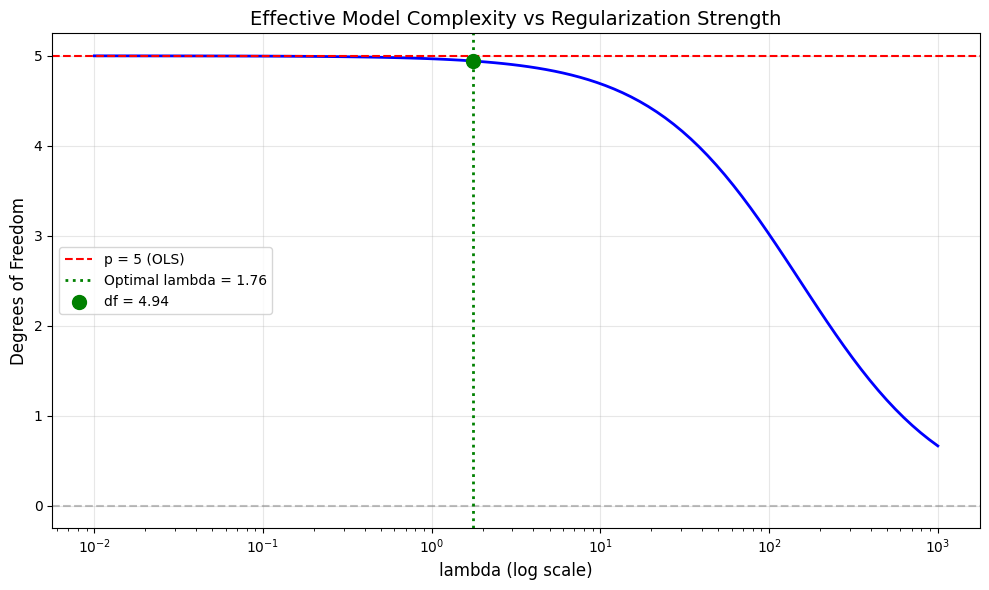

OLS (lambda = 0): df = 5
Ridge (lambda = 1.76): df = 4.942
Reduction: 0.058 (1.2%)
Direction 1 (s = 13.77): df = 0.9908 (99.1% of full)
Direction 2 (s = 12.41): df = 0.9887 (98.9% of full)
Direction 3 (s = 12.29): df = 0.9885 (98.8% of full)
Direction 4 (s = 11.85): df = 0.9876 (98.8% of full)
Direction 5 (s = 11.49): df = 0.9868 (98.7% of full)


In [20]:
lambda_values = np.logspace(-2, 3, 100)
df_values = []

model_dummy = RidgeRegressor(lambda_ = 1.0)
model_dummy.fit(X_train, y_train)
X_centered = X_train - model_dummy.X_mean_
_, S, _ = np.linalg.svd(X_centered, full_matrices = False)

for lam in lambda_values:

    df = np.sum(S ** 2 / (S ** 2 + lam))
    df_values.append(df)

plt.figure(figsize = (10, 6))
plt.plot(lambda_values, df_values, linewidth = 2, color = 'blue')
plt.axhline(X_train.shape[1], color = 'red', linestyle = '--', label = f'p = {X_train.shape[1]} (OLS)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

model_opt = RidgeRegressor(lambda_ = 1.76)
model_opt.fit(X_train, y_train)
df_opt = model_opt.dof(X_train)
plt.axvline(1.76, color = 'green', linestyle = ':', linewidth = 2, label = f'Optimal lambda = 1.76')
plt.scatter([1.76], [df_opt], color = 'green', s = 100, zorder = 5, label = f'df = {df_opt:.2f}')

plt.xscale('log')
plt.xlabel('lambda (log scale)', fontsize = 12)
plt.ylabel('Degrees of Freedom', fontsize = 12)
plt.title('Effective Model Complexity vs Regularization Strength', fontsize = 14)
plt.legend(fontsize = 10)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

print(f"OLS (lambda = 0): df = {X_train.shape[1]}")
print(f"Ridge (lambda = 1.76): df = {df_opt:.3f}")
print(f"Reduction: {X_train.shape[1] - df_opt:.3f} ({(1 - df_opt/X_train.shape[1]) * 100:.1f}%)")

for i, s in enumerate(S):

    df_i = s ** 2 / (s ** 2 + 1.76)
    print(f"Direction {i+1} (s = {s:.2f}): df = {df_i:.4f} ({df_i * 100:.1f}% of full)")

# **Benchmarking**

Loading the Boston Housing Data

In [21]:
from sklearn.datasets import fetch_openml

In [29]:
boston = fetch_openml(name = 'boston', version = 1, parser = 'auto', as_frame = False)

#Handling data type mismatch
X_b = boston.data.astype(float)
y_b = boston.target.astype(float)

print(f"Samples: {X_b.shape[0]}")
print(f"Features: {X_b.shape[1]}")
print(f"Feature names: {boston.feature_names}")
print(f"Range: ${y_b.min():.1f}k to ${y_b.max():.1f}k")

Samples: 506
Features: 13
Feature names: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Range: $5.0k to $50.0k


Creating a train/test split

In [30]:
from sklearn.model_selection import train_test_split as tts

X_train_b, X_test_b, y_train_b, y_test_b = tts(
    X_b, y_b, test_size = 0.2, random_state = 42
)

print(f"Train: {X_train_b.shape[0]}")
print(f"Test: {X_test_b.shape[0]}")

Train: 404
Test: 102


Metrics

In [38]:
from sklearn.linear_model import Ridge as SklearnRidge, LinearRegression
from sklearn.metrics import mean_squared_error as mse, r2_score as r2
import time

lambdas_test = [0.01, 0.1, 1.0, 10.0, 100.0]

for lam in lambdas_test:

    print(f"lambda = {lam}")

    # From scratch implementation
    t0 = time.time()
    model_scratch = RidgeRegressor(lambda_ = lam)
    model_scratch.fit(X_train_b, y_train_b)
    y_pred_scratch = model_scratch.predict(X_test_b)
    time_scratch = time.time() - t0

    mse_scratch = mse(y_test_b, y_pred_scratch)
    r2_scratch = r2(y_test_b, y_pred_scratch)

    # sklearn implementation
    t0 = time.time()
    model_sklearn = SklearnRidge(alpha = lam, fit_intercept = True)
    model_sklearn.fit(X_train_b, y_train_b)
    y_pred_sklearn = model_sklearn.predict(X_test_b)
    time_sklearn = time.time() - t0

    mse_sklearn = mse(y_test_b, y_pred_sklearn)
    r2_sklearn = r2(y_test_b, y_pred_sklearn)

    # Comparison
    print(f"\n{'Metric':<20} {'Scratch':>15} {'sklearn':>15} {'Difference':>15}\n")

    print(f"{'Test MSE':<20} {mse_scratch:>15.4f} {mse_sklearn:>15.4f} {abs(mse_scratch - mse_sklearn):>15.2e}")
    print(f"{'r2 Score':<20} {r2_scratch:>15.4f} {r2_sklearn:>15.4f} {abs(r2_scratch - r2_sklearn):>15.2e}")
    print(f"{'||beta||':<20} {np.linalg.norm(model_scratch.beta_):>15.4f} {np.linalg.norm(model_sklearn.coef_):>15.4f} {abs(np.linalg.norm(model_scratch.beta_) - np.linalg.norm(model_sklearn.coef_)):>15.2e}")
    print(f"{'Intercept':<20} {model_scratch.intercept_:>15.4f} {model_sklearn.intercept_:>15.4f} {abs(model_scratch.intercept_ - model_sklearn.intercept_):>15.2e}")
    print(f"{'Time (seconds)':<20} {time_scratch:>15.6f} {time_sklearn:>15.6f} {time_scratch / time_sklearn:>14.2f}x")

    # Coefficient comparison
    coef_diff = np.linalg.norm(model_scratch.beta_ - model_sklearn.coef_)
    print(f"\n{'Coefficient difference':<20} {coef_diff:>15.2e}")

    model_ols_scratch = OLSRegressor()
    model_ols_scratch.fit(X_train_b, y_train_b)
    y_pred_ols_scratch = model_ols_scratch.predict(X_test_b)

    model_ols_sklearn = LinearRegression()
    model_ols_sklearn.fit(X_train_b, y_train_b)
    y_pred_ols_sklearn = model_ols_sklearn.predict(X_test_b)

    print(f"\n{'Metric':<20} {'Scratch':>15} {'sklearn':>15} {'Difference':>15}")
    print(f"{'Test MSE':<20} {mse(y_test_b, y_pred_ols_scratch):>15.4f} {mse(y_test_b, y_pred_ols_sklearn):>15.4f} {abs(mse(y_test_b, y_pred_ols_scratch) - mse(y_test_b, y_pred_ols_sklearn)):>15.2e}")
    print(f"{'Coefficient difference':<20} {np.linalg.norm(model_ols_scratch.beta_ - model_ols_sklearn.coef_):>15.2e}")

lambda = 0.01

Metric                       Scratch         sklearn      Difference

Test MSE                     24.2917         24.2917        1.42e-14
r2 Score                      0.6688          0.6688        2.22e-16
||beta||                     17.9429         17.9429        4.26e-14
Intercept                    22.7965         30.1522        7.36e+00
Time (seconds)              0.000716        0.001616           0.44x

Coefficient difference        4.63e-14

Metric                       Scratch         sklearn      Difference
Test MSE                     24.2911         24.2911        3.55e-14
Coefficient difference        6.33e-14
lambda = 0.1

Metric                       Scratch         sklearn      Difference

Test MSE                     24.3010         24.3010        7.11e-15
r2 Score                      0.6686          0.6686        0.00e+00
||beta||                     16.8558         16.8558        5.68e-14
Intercept                    22.7965         29.3663        6